## Vectorless RAG 단계별 워크스루 🌳

이 노트북은 `tree.py` · `retriever.py` · `main.py`로 구성된 **벡터 없는(vectorless) RAG**
데모를 **한 단계씩 직접 실행**하며 동작 원리를 이해하기 위한 학습 자료입니다.

### RAG 방식 비교

| 구분 | 일반적인 RAG | **Vectorless RAG (이 프로젝트)** |
|------|--------------|-------------------------------|
| 색인 | 텍스트 → **임베딩 벡터** → 벡터 DB | PDF → **계층적 문서 트리** (임베딩 없음) |
| 검색 | "어떤 텍스트가 **유사**한가?" (벡터 유사도) | "다음에 **어디를 봐야** 하는가?" (LLM 추론) |
| 엔진 | 벡터 검색 라이브러리 | LangGraph **에이전트가 트리를 탐색** |

즉, 임베딩·벡터 DB 없이 **문서의 구조 그 자체를 색인으로** 쓰고,
LLM 에이전트가 루트에서 시작해 질문과 가장 관련 있는 자식으로 **내려가며(descend)** 답을 찾습니다.
데모 문서는 Google **Bigtable (OSDI'06)** 논문입니다.

### 이 노트북의 학습 흐름

아래로 내려갈수록 점점 큰 단위로 조립합니다. **작은 부품 → 전체 기계** 순서입니다.

```
  1. 환경 설정
        │
  2. tree.py        PDF ─▶ DocumentTree (검색 인덱스가 되는 트리)
        │
  3. RetrievalState  그래프 전체가 공유하는 '상태' 이해
        │
  4. 개별 노드       analyze ─▶ _route ─▶ descend ─▶ retrieve ─▶ generate
        │            (상태를 손으로 전이시키며 한 노드씩 호출)
  5. 그래프 빌드     4개 노드 + 분기를 LangGraph로 조립 & 시각화
        │
  6. 전체 실행       retrieve() 한 번으로 위 과정이 자동으로 도는 것 확인
        │
  7. 마무리 & 더 해보기
```

> ⚠️ **주의**: 4·6번 섹션은 **실제 Anthropic API를 호출**합니다(소량의 토큰 비용·지연 발생).
> `.env`에 유효한 `ANTHROPIC_API_KEY`가 있어야 합니다.

### 1. 환경 설정

1. 프로젝트 루트를 `sys.path`에 추가 → `import tree`, `import retriever`가 가능해짐
2. 작업 디렉터리를 루트로 변경(`os.chdir`) → `bigtable-osdi06.pdf`, `results/` 같은
   **상대 경로가 `main.py` 실행 때와 동일하게** 해석됨

In [1]:
import os, sys
from pathlib import Path

# 이 노트북(notebooks/)의 부모 = 프로젝트 루트
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

# 1) 모듈을 import할 수 있도록 루트를 sys.path에 추가
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 2) 상대 경로(PDF, results/)가 main.py와 동일하게 해석되도록 작업 디렉터리 이동
os.chdir(PROJECT_ROOT)

print('프로젝트 루트 :', PROJECT_ROOT)
print('작업 디렉터리 :', Path.cwd())
print('PDF 존재 여부 :', (PROJECT_ROOT / 'bigtable-osdi06.pdf').exists())

프로젝트 루트 : /Users/kmyu/Desktop/project/langchain-study/medium/3.vectorless-rag
작업 디렉터리 : /Users/kmyu/Desktop/project/langchain-study/medium/3.vectorless-rag
PDF 존재 여부 : True


#### API 키 로드 & 단일 클라이언트 생성

- **클라이언트는 단 하나만** 만들어 노트북 전체에서 재사용 (호출마다 새로 만들지 않음).
- 사용할 모델은 `retriever.DEFAULT_MODEL`이 **단일 출처**입니다
  (= `.env`의 `ANTHROPIC_MODEL`, 없으면 `claude-sonnet-4-6`). 모델명을 직접 하드코딩하지 않습니다.

In [2]:
import anthropic
from dotenv import load_dotenv
import retriever  # DEFAULT_MODEL 단일 출처

load_dotenv()  # .env에서 ANTHROPIC_API_KEY / ANTHROPIC_MODEL 로드

if not os.environ.get('ANTHROPIC_API_KEY'):
    raise SystemExit(
        'ANTHROPIC_API_KEY가 없습니다. 프로젝트 루트의 .env에 키를 설정하세요.\n'
        '  ANTHROPIC_API_KEY=...'
    )

# 노트북 전체에서 재사용할 단일 클라이언트 & 모델
client = anthropic.Anthropic(api_key=os.environ['ANTHROPIC_API_KEY'])
model = retriever.DEFAULT_MODEL

print('사용 모델:', model)
print('클라이언트 준비 완료 ✅')

사용 모델: claude-sonnet-4-6
클라이언트 준비 완료 ✅


### 2. `tree.py` — PDF를 문서 트리로

vectorless RAG의 **색인(index)** 단계입니다. 임베딩이 전혀 등장하지 않는다는 점에 주목하세요.

`PyMuPDF4LLMTreeBuilder`의 전략:
1. `pymupdf4llm`로 PDF를 **레이아웃을 보존한 마크다운**으로 변환
2. 마크다운 헤더(`#`, `##`, ...)를 **스택 기반으로 파싱**해 부모-자식 계층을 만듦
3. `page_chunks`로 각 노드의 **정확한 페이지 범위**를 보정

결과물은 `DocumentTree`(메타데이터 + 루트)이고, 그 안의 각 노드는 `TreeNode`입니다.

#### 2.1 PDF 파싱 실행

`parse_pdf()`를 호출해 PDF에서 직접 트리를 만들어 봅니다 (약 10~30초 소요).

> 참고: `main.py`는 결과를 `results/document_tree.json`에 **캐시**해 다음 실행부터는
> 파싱을 건너뜁니다. 이 노트북은 파싱 과정을 직접 보기 위해 **매번 메모리상에서 파싱**하며,
> 캐시 파일은 수정하지 않습니다.

In [3]:
from tree import parse_pdf, TreeNode, DocumentTree

doc_tree = parse_pdf('bigtable-osdi06.pdf')   # DocumentTree 반환
root = doc_tree.root                          # 최상위(루트) TreeNode

print()
print('문서 이름   :', doc_tree.document_name)
print('전체 페이지 :', doc_tree.total_pages)
print('최상위 섹션 :', len(root.children), '개')

🔍 Parsing bigtable-osdi06.pdf with PyMuPDF4LLM...
✅ Parsed in 4.16s: 14 pages, 37 nodes

문서 이름   : bigtable-osdi06
전체 페이지 : 14
최상위 섹션 : 1 개


#### 2.2 트리 구조 살펴보기

`DocumentTree.print_tree()`로 전체 계층을 들여쓰기와 함께 출력합니다.
이 트리가 바로 에이전트가 탐색할 **검색 인덱스**입니다.

In [4]:
doc_tree.print_tree()


📄 bigtable-osdi06 (14 pages)
📑 [0] bigtable-osdi06.pdf (p1-13)
  📖 [1] **Bigtable: A Distributed Storage System for Structured Data** (p1-13)
    📄 [2] **Abstract** (p1-1)
    📄 [2] **1 Introduction** (p1-1)
    📄 [2] **2 Data Model** (p1-1)
    📄 [2] **Rows** (p2-2)
    📄 [2] **Column Families** (p2-2)
    📄 [2] **Timestamps** (p2-2)
    📄 [2] Figure 2: Writing to Bigtable. (p3-3)
    📄 [2] **3 API** (p3-3)
    📄 [2] Figure 3: Reading from Bigtable. (p3-3)
    📄 [2] **4 Building Blocks** (p3-3)
    📄 [2] **5 Implementation** (p4-4)
    📄 [2] **5.1 Tablet Location** (p4-4)
    📄 [2] **5.2 Tablet Assignment** (p5-5)
    📄 [2] **5.3 Tablet Serving** (p6-6)
    📄 [2] **5.4 Compactions** (p6-6)
    📄 [2] **6** (p6-6)
    📄 [2] **Locality groups** (p6-6)
    📄 [2] **Caching for read performance** (p7-7)
    📄 [2]  (p6-6)
    📄 [2] **Compression** (p7-7)
    📄 [2] **Commit-log implementation** (p7-7)
    📄 [2] **Speeding up tablet recovery** (p8-8)
    📄 [2] **Exploiting immutability** (p8-

#### 2.3 `TreeNode` 한 개 살펴보기

노드 하나에는 어떤 정보가 들어 있을까요? 에이전트는 바로 이 필드들(특히 `title`/`summary`)을
보고 "여기로 내려갈지"를 판단합니다.

In [5]:
# 첫 번째 최상위 섹션 노드를 하나 골라 필드를 확인
sample = root.children[0]

print('id          :', sample.id)
print('title       :', sample.title)
print('level       :', sample.level, '  (0=루트, 1=챕터, 2=섹션 ...)')
print('pages       :', f'{sample.page_start}-{sample.page_end}')
print('heading_type:', sample.heading_type)
print('children    :', [c.title for c in sample.children] or '없음 (리프)')
print('summary     :', (sample.summary or '(없음)')[:200])
print('content[:200]:', (sample.content or '(없음)')[:200])

id          : Bigtable_A_Distribut_0
title       : **Bigtable: A Distributed Storage System for Structured Data**
level       : 1   (0=루트, 1=챕터, 2=섹션 ...)
pages       : 1-13
heading_type: unknown
children    : ['**Abstract**', '**1 Introduction**', '**2 Data Model**', '**Rows**', '**Column Families**', '**Timestamps**', 'Figure 2: Writing to Bigtable.', '**3 API**', 'Figure 3: Reading from Bigtable.', '**4 Building Blocks**', '**5 Implementation**', '**5.1 Tablet Location**', '**5.2 Tablet Assignment**', '**5.3 Tablet Serving**', '**5.4 Compactions**', '**6**', '**Locality groups**', '**Caching for read performance**', '', '**Compression**', '**Commit-log implementation**', '**Speeding up tablet recovery**', '**Exploiting immutability**', '**7 Performance Evaluation**', '**Single tablet-server performance**', '**Scaling**', '**8 Real Applications**', '**8.1 Google Analytics**', '**8.2 Google Earth**', '**8.3 Personalized Search**', '**9 Lessons**', '**10 Related Work**', '**Acknowledge

In [6]:
# to_dict()는 직렬화/디버깅용 요약본을 돌려준다
import json
print(json.dumps(sample.to_dict(), ensure_ascii=False, indent=2))

{
  "id": "Bigtable_A_Distribut_0",
  "title": "**Bigtable: A Distributed Storage System for Structured Data**",
  "level": 1,
  "pages": "1-13",
  "type": "unknown",
  "children_count": 35,
  "content_preview": "\n\nFay Chang, Jeffrey Dean, Sanjay Ghemawat, Wilson C. Hsieh, Deborah A. Wallach Mike Burrows, Tushar Chandra, Andrew Fikes, Robert E. Gruber \n\n{fay,jeff,sanjay,wilsonh,kerr,m3b,tushar,fikes,gruber}@go..."
}


#### 2.4 (참고) 캐시 저장/로드

실서비스 흐름인 `main.py`에서는:
- `get_tree()`가 `results/document_tree.json`이 있으면 **즉시 로드**하고,
  없으면 `parse_pdf()`로 빌드한 뒤 `asdict(tree)`로 직렬화해 캐시합니다.
- 로드 시에는 `dict_to_treenode()`가 중첩 dict를 재귀적으로 `TreeNode`로 복원합니다.

이 노트북은 학습 목적상 매번 파싱했지만, 반복 실행 시에는 캐시 로드가 훨씬 빠릅니다.

### 3. `RetrievalState` — 그래프가 공유하는 '상태'

LangGraph에서 각 노드는 **하나의 상태 딕셔너리**를 입력으로 받고, **변경분(dict)** 을 반환합니다.
`retriever.py`의 `RetrievalState`(`TypedDict`)가 그 상태의 스키마입니다.

| 필드 | 의미 | 갱신 방식 |
|------|------|-----------|
| `query` | 사용자 질문 | 덮어쓰기 |
| `current_node` | 지금 탐색 중인 노드 | 덮어쓰기 |
| `tree` | 전체 문서 트리(또는 루트) | 덮어쓰기 |
| `depth` | 현재 탐색 깊이(루트=0) | 덮어쓰기 |
| `confidence` | 이 노드가 답을 가질 확신도(0~1) | 덮어쓰기 |
| `should_descend` / `target_child_id` | 더 내려갈지 / 내려갈 자식 | 덮어쓰기 |
| `reasoning` | 마지막 판단 근거 | 덮어쓰기 |
| `final_answer` | 최종 답변 | 덮어쓰기 |
| **`path_taken`** | 거쳐온 노드 id 경로 | **누적(append)** |
| **`retrieved_content`** | 수집한 본문 청크 | **누적(append)** |
| **`call_log`** | 모든 LLM 호출 기록 | **누적(append)** |

굵게 표시된 세 필드는 `Annotated[List[...], operator.add]`로 선언되어,
노드가 반환한 값이 **덮어쓰기가 아니라 기존 값에 이어 붙습니다**.
덕분에 여러 노드를 거치며 경로·수집본문·호출로그가 차곡차곡 쌓입니다.

In [7]:
from retriever import RetrievalState
import typing

# RetrievalState의 필드 목록 확인
for name in RetrievalState.__annotations__:
    print('-', name)

- query
- current_node
- tree
- path_taken
- retrieved_content
- reasoning
- confidence
- should_descend
- target_child_id
- depth
- final_answer
- call_log


### 4. 개별 노드 단계 테스트

이제 그래프를 조립하기 **전에**, 노드 함수를 하나씩 직접 호출해 봅니다.
각 노드는 `state` 딕셔너리를 받아 변경분 dict를 돌려줍니다. 우리는 그 변경분을
`state = {**state, **out}`로 손수 합치며 **상태가 노드를 거쳐 변해 가는 과정**을 따라갑니다.

> `retriever.py`는 `_make_analyze(client, model)`처럼 **팩토리 함수**로 노드를 만듭니다.
> client/model을 클로저에 가둔 채 LangGraph 시그니처(`state -> dict`)를 유지하기 위한 패턴입니다.

#### 4.0 로깅 켜기

`retriever`는 전용 로거를 갖고 있습니다. 콘솔에는 INFO(요약), `retriever.log` 파일에는
DEBUG(전체 프롬프트·원문 응답)까지 남습니다. 노트북 셀 출력에서 탐색 과정을 보려면
로거의 핸들러가 노트북 stdout으로 흐르도록 두면 됩니다(모듈 import 시 기본 설정됨).
전체 프롬프트까지 콘솔에서 보고 싶다면 아래처럼 레벨을 DEBUG로 낮출 수 있습니다(선택).

In [8]:
import logging
log = logging.getLogger('retriever')

# 콘솔 핸들러는 기본 INFO. 필요하면 아래 주석을 풀어 전체 프롬프트까지 콘솔에서 확인:
# for h in log.handlers:
#     if isinstance(h, logging.StreamHandler) and not isinstance(h, logging.FileHandler):
#         h.setLevel(logging.DEBUG)

print('로거 준비 완료 — 콘솔에는 INFO 요약, retriever.log에는 DEBUG 전체가 남습니다.')

로거 준비 완료 — 콘솔에는 INFO 요약, retriever.log에는 DEBUG 전체가 남습니다.


#### 4.1 초기 상태 만들기

`retrieve()`가 `graph.invoke()`에 넘기는 **초기 상태와 동일하게** 손으로 구성합니다.
- `current_node=None` → analyze 노드가 알아서 트리 루트를 시작점으로 잡습니다.
- `tree`에는 루트 `TreeNode`를 넣습니다(`main.py`와 동일). analyze는 `DocumentTree`/`TreeNode`
  둘 다 받아 처리합니다.

In [9]:
from questions import QUESTIONS

query = QUESTIONS[0]
print('질문:', query)

state = {
    'query':             query,
    'current_node':      None,
    'tree':              root,     # 루트 TreeNode
    'path_taken':        [],
    'retrieved_content': [],
    'reasoning':         '',
    'confidence':        0.0,
    'should_descend':    True,
    'target_child_id':   None,
    'depth':             0,
    'final_answer':      None,
    'call_log':          [],
}
print('초기 depth =', state['depth'], '| current_node =', state['current_node'])

질문: Bigtable이란 무엇이며 어떤 문제를 해결하는가?
초기 depth = 0 | current_node = None


#### 4.2 `analyze` 노드 — "여기서 답을 찾을까, 더 내려갈까?"

현재 노드와 그 자식 목록을 LLM에게 보여주고, **JSON으로** 다음을 판단하게 합니다.
`confidence` / `should_descend` / `target_child_id` / `reasoning`.

아래 셀은 **실제 LLM을 1회 호출**합니다.

In [10]:
analyze = retriever._make_analyze(client, model)

out = analyze(state)        # 실제 LLM 호출 (navigate)
state = {**state, **out}    # 변경분을 손으로 병합해 상태 전이

print('\n── analyze 결과 ──')
print('confidence     :', state['confidence'])
print('should_descend :', state['should_descend'])
print('target_child_id:', state['target_child_id'])
print('reasoning      :', state['reasoning'])
print('depth (1 증가)  :', state['depth'])
print('path_taken     :', state['path_taken'])


┌─ Depth 0 | Node: "bigtable-osdi06.pdf"
│  id=root  pages=1-13
│  children=['**Bigtable: A Distributed Storage System for Structured Data**']

─────────────────────────────────────────────────────────────────
  LLM Call #1  [NAVIGATE]
─────────────────────────────────────────────────────────────────
  Model    : claude-sonnet-4-6
  Latency  : 8.81s
  Tokens   : 558 in / 112 out
│
│  Decision   : ↓ descend
│  Confidence : 95%
│  Next node  : Bigtable_A_Distribut_0
│  Reasoning  : 자식 노드가 Bigtable의 정의와 목적을 직접 다루는 논문 본문이므로 해당 노드로 내려가는 것이 적합하다.
└─ (8.81s)



── analyze 결과 ──
confidence     : 0.95
should_descend : True
target_child_id: Bigtable_A_Distribut_0
reasoning      : 자식 노드가 Bigtable의 정의와 목적을 직접 다루는 논문 본문이므로 해당 노드로 내려가는 것이 적합하다.
depth (1 증가)  : 1
path_taken     : ['root']


#### 4.3 `_route` — 다음에 어디로 갈지 분기

`analyze` 다음에는 `_route(state)`가 문자열을 돌려주고, 그 값이 다음에 실행할 노드를 가리킵니다.
규칙:
1. `confidence < 0.3` → `'end'` (확신이 너무 낮아 중단)
2. `depth >= MAX_DEPTH(=5)` → `'retrieve'` (너무 깊어졌으니 현재 노드에서 수집)
3. `should_descend` 이고 자식이 있으면 → `'descend'`
4. 그 외 → `'retrieve'`

In [11]:
decision = retriever._route(state)
print('MAX_DEPTH =', retriever.MAX_DEPTH)
print('_route 결정:', decision)

MAX_DEPTH = 5
_route 결정: descend


#### 4.4 `descend` 노드 — 선택한 자식으로 이동

`_route`가 `'descend'`라면, `descend` 노드가 `target_child_id`에 해당하는 자식으로
`current_node`를 옮깁니다. (분기가 `'descend'`가 아니라면 이 셀은 건너뛰고 4.6 retrieve로 가세요.)

In [12]:
if decision == 'descend':
    descend = retriever._make_descend()
    out = descend(state)
    state = {**state, **out}
    print('이동한 노드 :', state['current_node'].title)
    print('현재 depth  :', state['depth'])
else:
    print("분기가 'descend'가 아닙니다 → 4.6 retrieve 셀로 이동하세요. (decision=" + decision + ')')


  ➜  Descending into: "**Bigtable: A Distributed Storage System for Structured Data**"


이동한 노드 : **Bigtable: A Distributed Storage System for Structured Data**
현재 depth  : 1


#### 4.5 더 내려가기 (선택적 반복)

`descend` 다음에는 다시 `analyze`로 돌아갑니다(그래프의 `descend → analyze` 엣지).
아래 셀은 `_route`가 더 이상 `'descend'`가 아닐 때까지(=리프에 도달하거나 수집 결정) **자동 반복**하며
트리를 내려가는 과정을 한 번에 보여줍니다. 한 번에 한 노드씩 LLM을 호출합니다.

In [13]:
# analyze ─▶ _route ─▶ (descend ─▶ analyze) 루프를 retrieve/end 직전까지 반복
while True:
    out = analyze(state)
    state = {**state, **out}
    decision = retriever._route(state)
    print(f"depth={state['depth']:>2} | conf={state['confidence']:.0%} | decision={decision} | node='{state['current_node'].title}'")
    if decision != 'descend':
        break
    out = retriever._make_descend()(state)
    state = {**state, **out}

print('\n탐색 종료 — 최종 분기:', decision)
print('지금까지 경로:', ' → '.join(state['path_taken']))


  ┌─ Depth 1 | Node: "**Bigtable: A Distributed Storage System for Structured Data**"
  │  id=Bigtable_A_Distribut_0  pages=1-13
  │  children=['**Abstract**', '**1 Introduction**', '**2 Data Model**', '**Rows**', '**Column Families**', '**Timestamps**', 'Figure 2: Writing to Bigtable.', '**3 API**', 'Figure 3: Reading from Bigtable.', '**4 Building Blocks**', '**5 Implementation**', '**5.1 Tablet Location**', '**5.2 Tablet Assignment**', '**5.3 Tablet Serving**', '**5.4 Compactions**', '**6**', '**Locality groups**', '**Caching for read performance**', '', '**Compression**', '**Commit-log implementation**', '**Speeding up tablet recovery**', '**Exploiting immutability**', '**7 Performance Evaluation**', '**Single tablet-server performance**', '**Scaling**', '**8 Real Applications**', '**8.1 Google Analytics**', '**8.2 Google Earth**', '**8.3 Personalized Search**', '**9 Lessons**', '**10 Related Work**', '**Acknowledgements**', '**References**', '**11 Conclusions**']

───────────────

depth= 2 | conf=98% | decision=descend | node='**Bigtable: A Distributed Storage System for Structured Data**'


  Model    : claude-sonnet-4-6
  Latency  : 4.99s
  Tokens   : 605 in / 202 out
    │
    │  Decision   : → retrieve
    │  Confidence : 88%
    │  Reasoning  : 현재 노드의 Abstract가 Bigtable의 정의(구조화된 데이터를 위한 분산 스토리지 시스템)와 해결하는 문제(페타바이트 규모의 데이터를 수천 대의 서버에서 관리, 다양한 데이터 크기와 지연 요구사항 처리)를 충분히 설명하고 있으며, 자식 노드가 없는 리프 노드이므로 더 이상 탐색할 필요가 없다.
    └─ (4.99s)


depth= 3 | conf=88% | decision=retrieve | node='**Abstract**'

탐색 종료 — 최종 분기: retrieve
지금까지 경로: Abstract_8


#### 4.6 `retrieve` 노드 — 최종 노드의 본문 수집

답을 찾을 노드에 도달하면, `retrieve` 노드가 그 노드의 **본문에 제목/페이지 헤더를 붙여**
`retrieved_content`에 쌓습니다. (이 단계는 LLM을 호출하지 않습니다.)

In [14]:
if decision == 'retrieve':
    retrieve_node = retriever._make_retrieve()
    out = retrieve_node(state)
    state = {**state, **out}
    print('수집된 청크 수:', len(state['retrieved_content']))
    print('첫 청크 헤더  :', state['retrieved_content'][0].splitlines()[0])
    print('본문 길이     :', len(state['retrieved_content'][0]), 'chars')
else:
    print("분기가 'end'(저확신)라 수집할 본문이 없습니다. 다른 질문으로 다시 시도해 보세요.")


      ✦  Retrieving content from: "**Abstract**"
         Pages 1–1 | 830 chars


수집된 청크 수: 1
첫 청크 헤더  : === ****Abstract**** (Pages 1-1) ===
본문 길이     : 867 chars


#### 4.7 `generate` 노드 — 수집한 본문만 근거로 답변 생성

마지막으로 `generate` 노드가 **수집된 청크만을 근거로** 최종 답변을 생성합니다.
프롬프트는 "근거가 부족하면 추측하지 말 것, 주장마다 섹션·페이지를 인용할 것"을 지시합니다.

아래 셀은 **실제 LLM을 1회 호출**합니다 (answer).

In [15]:
if state['retrieved_content']:
    generate = retriever._make_generate(client, model)
    out = generate(state)
    state = {**state, **out}
    print('\n──────── 최종 답변 ────────\n')
    print(state['final_answer'])
else:
    print('수집된 본문이 없어 답변을 생성할 수 없습니다.')


─────────────────────────────────────────────────────────────────
  Generating answer from 1 retrieved section(s):
    • === ****Abstract**** (Pages 1-1) ===

─────────────────────────────────────────────────────────────────
  LLM Call #2  [ANSWER]
─────────────────────────────────────────────────────────────────
  Model    : claude-sonnet-4-6
  Latency  : 13.14s
  Tokens   : 390 in / 720 out

  Answer generated in 13.14s



──────── 최종 답변 ────────

## Bigtable란 무엇이며 어떤 문제를 해결하는가?

### 정의

**Abstract (Pages 1-1)** 에 따르면, Bigtable은 **구조화된 데이터(structured data)를 관리하기 위한 분산 스토리지 시스템(distributed storage system)** 입니다.

---

### 해결하는 문제

**Abstract (Pages 1-1)** 에 근거하여, Bigtable은 다음과 같은 문제들을 해결합니다:

1. **대규모 확장성 문제**
   - 수천 대의 범용 서버(commodity servers)에 걸쳐 **페타바이트(petabytes) 규모**의 데이터를 처리할 수 있도록 설계되었습니다.

2. **다양한 데이터 크기 요구사항**
   - URL처럼 작은 데이터부터 웹 페이지, 위성 이미지처럼 대용량 데이터까지 **다양한 크기의 데이터**를 수용합니다.

3. **다양한 지연시간(Latency) 요구사항**
   - 백엔드 대량 처리(backend bulk processing)부터 **실시간 데이터 서빙(real-time data serving)** 까지 상이한 지연시간 요구사항을 동시에 충족합니다.

4. **유연한 데이터 레이아웃 제어**
   - 클라이언트가 **데이터 레이아웃과 포맷을 동적으로 제어(dynamic control over data layout and format)** 할 수 있는 단순한 데이터 모델을 제공합니다.

---

### 실제 활용 사례

**Abstract (Pages 1-1)** 에 따르면, Google 내부에서 다음 프로젝트들이 Bigtable을 사용합니다:
- **웹 인덱싱(Web Indexing)**
- **Google Earth**
- **Google Finance**

---

### 한계 (근거 부족 명시)

제공된 구간은 Abstract(1페이지)에 한정되어 있으므로, Bigtable의 내부 아키텍처, 구체적인 구현 방식, 또는

여기까지가 **노드 단위로 손수 따라간** 전체 흐름입니다.
`analyze → _route → descend → (반복) → retrieve → generate`.
다음 섹션에서는 이 노드들을 LangGraph로 **조립**해, 위 과정을 자동으로 돌립니다.

### 5. 전체 그래프 빌드 & 시각화

`_build_graph(client, model)`는 4개 노드와 분기 규칙을 엮어 **실행 가능한 그래프**로 컴파일합니다.

```
            ┌─ (confidence < 0.3) ───────────────▶ END
  analyze ──┼─ (should_descend & 자식 존재) ─ descend ─▶ analyze (재귀)
            ├─ (depth >= MAX_DEPTH) ─────────────▶ retrieve
            └─ (그 외) ──────────────────────────▶ retrieve ─▶ generate ─▶ END
```

In [16]:
graph = retriever._build_graph(client, model)
print('그래프 컴파일 완료 ✅')
print('노드 목록:', list(graph.get_graph().nodes))

그래프 컴파일 완료 ✅
노드 목록: ['__start__', 'analyze', 'descend', 'retrieve', 'generate', '__end__']


#### 5.1 워크플로 PNG로 시각화

`generate_workflow_png()`는 그래프 **구조**(동작 아닌 형태)를 Mermaid PNG로 렌더링합니다.
`results/workflow.png`로 저장한 뒤 노트북에 인라인으로 표시합니다.

Workflow visualization saved to: results/workflow.png


저장 경로: results/workflow.png


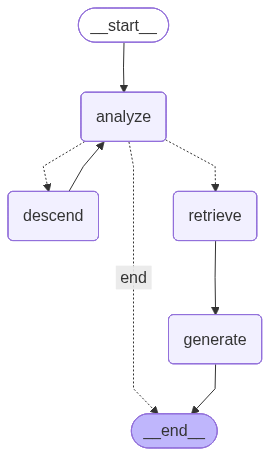

In [17]:
from IPython.display import Image, display

png_path = retriever.generate_workflow_png('results/workflow.png')
print('저장 경로:', png_path)
display(Image(filename=png_path))

#### 5.2 (참고) Mermaid 텍스트로도 확인

PNG 렌더링이 어려운 환경에서는 Mermaid 소스 텍스트로 구조를 확인할 수 있습니다.

In [18]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	analyze(analyze)
	descend(descend)
	retrieve(retrieve)
	generate(generate)
	__end__([<p>__end__</p>]):::last
	__start__ --> analyze;
	analyze -. &nbsp;end&nbsp; .-> __end__;
	analyze -.-> descend;
	analyze -.-> retrieve;
	descend --> analyze;
	retrieve --> generate;
	generate --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### 6. 전체 그래프 실행 (end-to-end) 🚀

이제 공개 API인 `retrieve(query, tree, client)` 한 번으로, 4번에서 손으로 따라간 과정이
**자동으로 한 번에** 도는 것을 확인합니다. (내부에서 여러 번 LLM을 호출합니다.)

In [19]:
result = retriever.retrieve(query, root, client)   # 콘솔에 탐색 로그가 함께 출력됩니다


═════════════════════════════════════════════════════════════════
  New Query
═════════════════════════════════════════════════════════════════

  Q: Bigtable이란 무엇이며 어떤 문제를 해결하는가?


┌─ Depth 0 | Node: "bigtable-osdi06.pdf"
│  id=root  pages=1-13
│  children=['**Bigtable: A Distributed Storage System for Structured Data**']

─────────────────────────────────────────────────────────────────
  LLM Call #1  [NAVIGATE]
─────────────────────────────────────────────────────────────────
  Model    : claude-sonnet-4-6
  Latency  : 3.85s
  Tokens   : 558 in / 117 out
│
│  Decision   : ↓ descend
│  Confidence : 95%
│  Next node  : Bigtable_A_Distribut_0
│  Reasoning  : 자식 노드가 Bigtable의 정의와 목적을 직접 다루는 논문 본문이므로 질의에 대한 답을 포함할 가능성이 매우 높다.
└─ (3.85s)

  ➜  Descending into: "**Bigtable: A Distributed Storage System for Structured Data**"

  ┌─ Depth 1 | Node: "**Bigtable: A Distributed Storage System for Structured Data**"
  │  id=Bigtable_A_Distribut_0  pages=1-13
  │  children=['**Abstract**', '**1 

#### 6.1 결과 dict 살펴보기

`retrieve()`는 `answer / path / reasoning / confidence / sources / call_log`를 돌려줍니다.

In [20]:
print('확신도   :', f"{result['confidence']:.0%}")
print('판단 근거:', result['reasoning'])
print('탐색 경로:', ' → '.join(result['path']))
print()
print('[출처]')
for src in result['sources'][:2]:
    print('  •', src.splitlines()[0])
print()
print('[답변]\n')
print(result['answer'])

확신도   : 88%
판단 근거: 현재 노드의 Abstract가 Bigtable의 정의(구조화된 데이터를 위한 분산 스토리지 시스템)와 해결하는 문제(페타바이트 규모의 데이터를 수천 대의 서버에서 관리, 다양한 데이터 크기와 지연 요구사항 처리)를 이미 충분히 설명하고 있으며, 자식 노드도 존재하지 않는 리프 노드이다.
탐색 경로: root → Bigtable_A_Distribut_0 → Abstract_8

[출처]
  • === ****Abstract**** (Pages 1-1) ===

[답변]

## Bigtable이란 무엇이며 어떤 문제를 해결하는가?

### 정의

**Abstract (Pages 1-1)** 에 따르면, Bigtable은 **구조화된 데이터(structured data)를 관리하기 위한 분산 스토리지 시스템(distributed storage system)** 입니다.

---

### 해결하는 문제

**Abstract (Pages 1-1)** 를 근거로, Bigtable은 다음과 같은 문제들을 해결합니다:

1. **대규모 확장성 문제**
   - 수천 대의 범용 서버(commodity servers)에 걸쳐 **페타바이트(petabytes) 규모**의 데이터를 처리할 수 있도록 설계되었습니다.

2. **다양한 데이터 크기 요구사항**
   - URL, 웹 페이지, 위성 이미지 등 크기가 매우 다른 다양한 유형의 데이터를 하나의 시스템에서 처리합니다.

3. **다양한 지연 시간(latency) 요구사항**
   - 백엔드 대량 처리(backend bulk processing)부터 실시간 데이터 서빙(real-time data serving)까지 상이한 지연 요구사항을 동시에 충족합니다.

4. **유연한 데이터 레이아웃 제어**
   - 클라이언트가 **데이터 레이아웃과 포맷을 동적으로 제어(dynamic control over data layout and format)** 할 수 있는 단순한 데이터 모델을 제공합니다.

-

#### 6.2 호출 로그(`call_log`) 분석

에이전트가 몇 번이나 LLM을 호출했고(탐색용 navigate vs 답변용 answer),
어떤 노드를 거쳤는지 집계해 봅니다.

In [21]:
call_log = result['call_log']
nav = [c for c in call_log if c['call_type'] == 'navigate']
ans = [c for c in call_log if c['call_type'] == 'answer']

print(f'총 LLM 호출: {len(call_log)}회  ({len(nav)} navigate + {len(ans)} answer)')
print(f"총 지연시간 : {sum(c['latency_s'] for c in call_log):.2f}s")
print()
print('탐색 단계별 판단:')
for c in nav:
    arrow = '↓ descend' if c['should_descend'] else '→ retrieve'
    print(f"  depth {c['depth']} | conf {c['confidence']:.0%} | {arrow} | {c['node_title']}")

총 LLM 호출: 4회  (3 navigate + 1 answer)
총 지연시간 : 24.77s

탐색 단계별 판단:
  depth 0 | conf 95% | ↓ descend | bigtable-osdi06.pdf
  depth 1 | conf 98% | ↓ descend | **Bigtable: A Distributed Storage System for Structured Data**
  depth 2 | conf 88% | → retrieve | **Abstract**


### 7. 마무리 & 더 해보기

#### 핵심 정리
- **색인**: PDF → 계층적 `DocumentTree` (임베딩·벡터 DB 없음). 트리 구조 자체가 인덱스.
- **검색**: LLM 에이전트가 `analyze`로 "더 내려갈지/여기서 수집할지"를 판단하며 트리를 탐색.
- **상태 기계**: `RetrievalState`가 노드를 거치며 경로·수집본문·호출로그를 누적.
- **답변**: 수집한 섹션만 근거로 인용과 함께 생성.

즉, "무엇이 유사한가"(벡터)가 아니라 **"다음에 어디를 봐야 하는가"(추론)** 로 검색을 푼 것입니다.

#### 더 해보기
- **다른 질문**: `questions.py`의 `QUESTIONS`에서 주석을 풀어 추론·교차 섹션 질문을 시도
  (예: "Bigtable은 태블릿 서버 장애와 복구를 어떻게 처리하는가?"). 4.1의 `query`만 바꿔 재실행.
- **탐색 깊이 조정**: `retriever.MAX_DEPTH`(기본 5)를 바꿔 더 깊게/얕게 탐색.
- **프롬프트 관찰**: `retriever.log`(DEBUG)에 매 호출의 **전체 프롬프트와 원문 응답**이 남습니다.
- **전체 파이프라인**: 터미널에서 `uv run main.py`로 캐시 기반의 실제 실행 흐름을 확인.